## Vehical Price Prediction 

In [229]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [230]:
df= pd.read_csv('VehicalDataSet.csv')


In [231]:
df.head()

,name,description,make,model,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain
0,2024 Jeep Wagoneer Series II,"\n \n Heated Leather Seats, Nav Sy...",Jeep,Wagoneer,2024,74600.0,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,Series II,SUV,4.0,White,Global Black,Four-wheel Drive
1,2024 Jeep Grand Cherokee Laredo,Al West is committed to offering every custome...,Jeep,Grand Cherokee,2024,50170.0,OHV,6.0,Gasoline,1.0,8-Speed Automatic,Laredo,SUV,4.0,Metallic,Global Black,Four-wheel Drive
2,2024 GMC Yukon XL Denali,NaN,GMC,Yukon XL,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",8.0,Gasoline,0.0,Automatic,Denali,SUV,4.0,Summit White,Teak/Light Shale,Four-wheel Drive
3,2023 Dodge Durango Pursuit,White Knuckle Clearcoat 2023 Dodge Durango Pur...,Dodge,Durango,2023,46835.0,16V MPFI OHV,8.0,Gasoline,32.0,8-Speed Automatic,Pursuit,SUV,4.0,White Knuckle Clearcoat,Black,All-wheel Drive
4,2024 RAM 3500 Laramie,\n \n 2024 Ram 3500 Laramie Billet...,RAM,3500,2024,81663.0,24V DDI OHV Turbo Diesel,6.0,Diesel,10.0,6-Speed Automatic,Laramie,Pickup Truck,4.0,Silver,Black,Four-wheel Drive


In [232]:
df.columns

Index(['name', 'description', 'make', 'model', 'year', 'price', 'engine',
       'cylinders', 'fuel', 'mileage', 'transmission', 'trim', 'body', 'doors',
       'exterior_color', 'interior_color', 'drivetrain'],
      dtype='object')

In [233]:
df = df.drop(columns=['description'])

In [234]:
df.head(3)

,name,make,model,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain
0,2024 Jeep Wagoneer Series II,Jeep,Wagoneer,2024,74600.0,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,Series II,SUV,4.0,White,Global Black,Four-wheel Drive
1,2024 Jeep Grand Cherokee Laredo,Jeep,Grand Cherokee,2024,50170.0,OHV,6.0,Gasoline,1.0,8-Speed Automatic,Laredo,SUV,4.0,Metallic,Global Black,Four-wheel Drive
2,2024 GMC Yukon XL Denali,GMC,Yukon XL,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",8.0,Gasoline,0.0,Automatic,Denali,SUV,4.0,Summit White,Teak/Light Shale,Four-wheel Drive


In [235]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            1002 non-null   object 
 1   make            1002 non-null   object 
 2   model           1002 non-null   object 
 3   year            1002 non-null   int64  
 4   price           979 non-null    float64
 5   engine          1000 non-null   object 
 6   cylinders       897 non-null    float64
 7   fuel            995 non-null    object 
 8   mileage         968 non-null    float64
 9   transmission    1000 non-null   object 
 10  trim            1001 non-null   object 
 11  body            999 non-null    object 
 12  doors           995 non-null    float64
 13  exterior_color  997 non-null    object 
 14  interior_color  964 non-null    object 
 15  drivetrain      1002 non-null   object 
dtypes: float64(4), int64(1), object(11)
memory usage: 125.4+ KB


In [236]:
df.describe()

,year,price,cylinders,mileage,doors
count,1002.000000,979.000000,897.000000,968.000000,995.000000
mean,2023.916168,50202.985700,4.975474,69.033058,3.943719
std,0.298109,18700.392062,1.392526,507.435745,0.274409
min,2023.000000,0.000000,0.000000,0.000000,2.000000
25%,2024.000000,36600.000000,4.000000,4.000000,4.000000
50%,2024.000000,47165.000000,4.000000,8.000000,4.000000
75%,2024.000000,58919.500000,6.000000,13.000000,4.000000
max,2025.000000,195895.000000,8.000000,9711.000000,5.000000


In [237]:
df.dtypes

name               object
make               object
model              object
year                int64
price             float64
engine             object
cylinders         float64
fuel               object
mileage           float64
transmission       object
trim               object
body               object
doors             float64
exterior_color     object
interior_color     object
drivetrain         object
dtype: object

### Outliers and Null value Treatment 

In [238]:
df.isna().sum()

name                0
make                0
model               0
year                0
price              23
engine              2
cylinders         105
fuel                7
mileage            34
transmission        2
trim                1
body                3
doors               7
exterior_color      5
interior_color     38
drivetrain          0
dtype: int64

<Axes: >

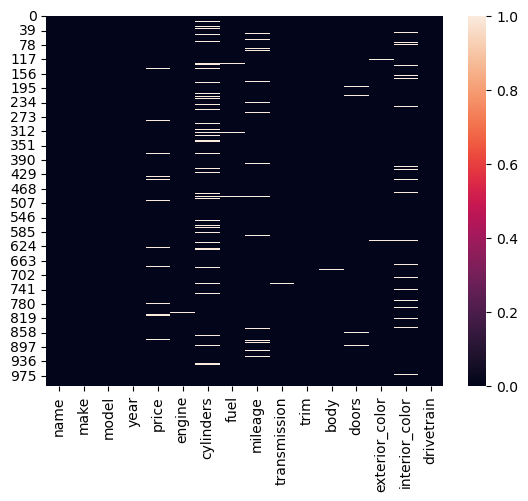

In [239]:
sns.heatmap(data = df.isna())

<Axes: ylabel='cylinders'>

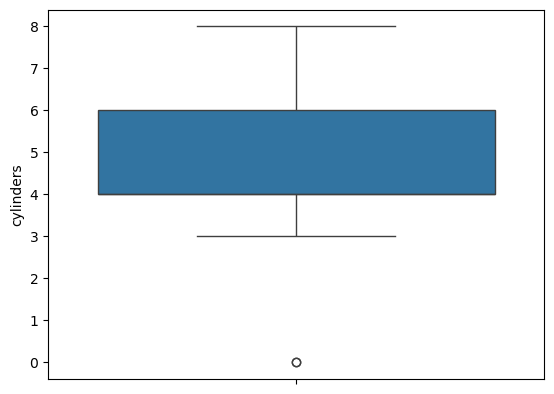

In [240]:
sns.boxplot(data = df,y ='cylinders')

In [241]:
df.cylinders.value_counts()

cylinders
4.0    502
6.0    277
8.0     89
3.0     27
0.0      2
Name: count, dtype: int64

In [242]:
df.cylinders.isna().sum()

np.int64(105)

In [243]:
df['cylinders'].fillna(df.cylinders.mode()[0],inplace=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_9932\3812102702.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cylinders'].fillna(df.cylinders.mode()[0],inplace=True)


In [244]:
df.cylinders.astype('Int64')

0       6
1       6
2       8
3       8
4       6
       ..
997     4
998     4
999     6
1000    6
1001    8
Name: cylinders, Length: 1002, dtype: Int64

In [245]:
df.cylinders.replace(0,df.cylinders.mode()[0],inplace=True)
df[df.cylinders == 0]

C:\Users\Dell\AppData\Local\Temp\ipykernel_9932\1951140059.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.cylinders.replace(0,df.cylinders.mode()[0],inplace=True)


,name,make,model,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain


<Axes: >

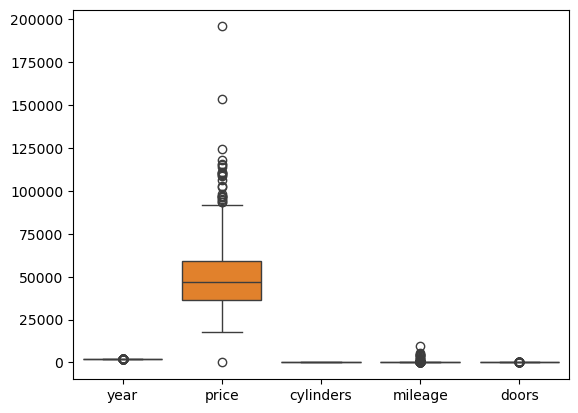

In [246]:
sns.boxplot(data = df)

<Axes: xlabel='price', ylabel='Count'>

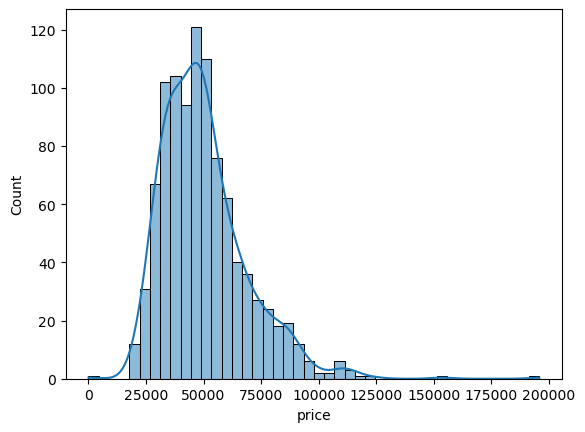

In [247]:
sns.histplot(df['price'], kde=True)

In [248]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
Outliers = df[(df['price']<lower_bound)| (df['price']>upper_bound)]

len(Outliers)
#Outliers

26

#### Z Score outlier Treatment


In [249]:
# from scipy.stats import zscore
# df['z_score'] = zscore(df['price'])
# outliers = df[df['z_score'].abs() > 2.4]
# len(outliers)


In [250]:
# df['price'] = df['price'].apply(lambda x: upper_bound if x > upper_bound else (lower_bound if x < lower_bound else x))

In [251]:
df['price'] = df['price'].fillna(df['price'].median())

In [252]:

df['log_price'] = np.log1p(df['price'])

<Axes: xlabel='log_price', ylabel='Count'>

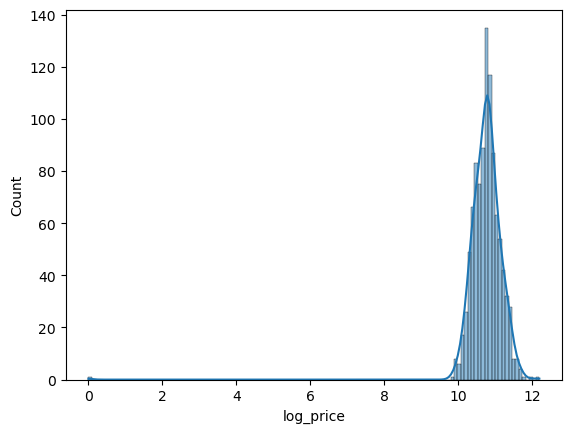

In [253]:
sns.histplot(df['log_price'], kde=True)

<Axes: ylabel='mileage'>

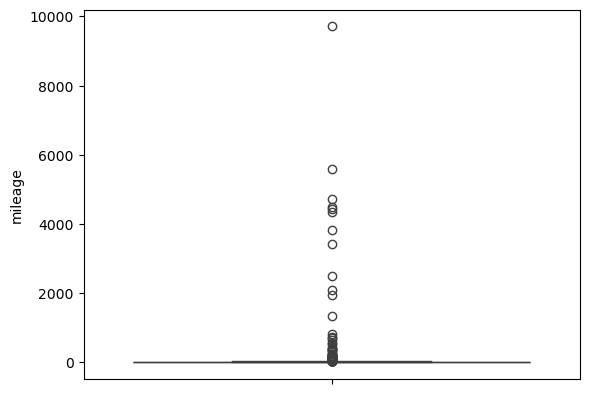

In [254]:
sns.boxplot(y=df['mileage'])

<Axes: xlabel='mileage', ylabel='Count'>

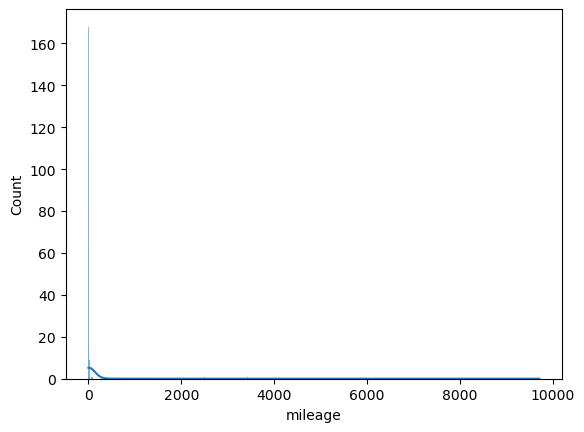

In [255]:
sns.histplot(df['mileage'],kde =True)

In [256]:
import pandas as pd

# Example: Create 5 bins from min to max mileage
bins = pd.cut(df['mileage'], bins=3)
df['mileage_bin'] = bins


<Axes: xlabel='mileage_bin', ylabel='mileage'>

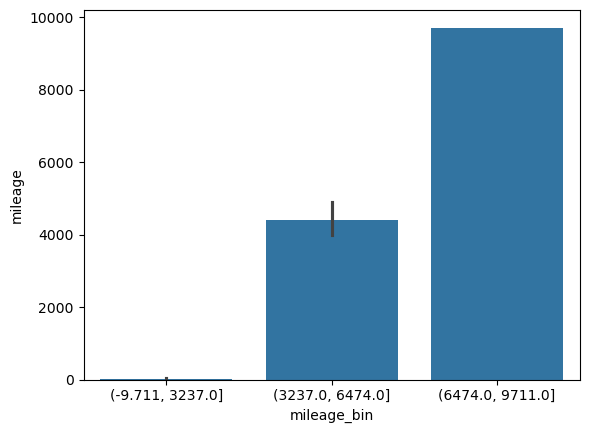

In [257]:
sns.barplot(x = df['mileage_bin'],y = df['mileage'])

In [258]:
df.drop(columns='mileage_bin',inplace = True)

In [259]:
df['mileage'] = df['mileage'].fillna(df['mileage'].median())

In [260]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            1002 non-null   object 
 1   make            1002 non-null   object 
 2   model           1002 non-null   object 
 3   year            1002 non-null   int64  
 4   price           1002 non-null   float64
 5   engine          1000 non-null   object 
 6   cylinders       1002 non-null   float64
 7   fuel            995 non-null    object 
 8   mileage         1002 non-null   float64
 9   transmission    1000 non-null   object 
 10  trim            1001 non-null   object 
 11  body            999 non-null    object 
 12  doors           995 non-null    float64
 13  exterior_color  997 non-null    object 
 14  interior_color  964 non-null    object 
 15  drivetrain      1002 non-null   object 
 16  log_price       1002 non-null   float64
dtypes: float64(5), int64(1), object(1

In [261]:
df['fuel'] = df['fuel'].fillna(df['fuel'].mode()[0])

In [262]:
df['trim'] = df['trim'].fillna(df['trim'].mode()[0])

In [263]:
df['body'] = df['body'].fillna(df['body'].mode()[0])

In [264]:
df['doors'] = df['doors'].fillna(df['doors'].mode()[0])

In [265]:
df['interior_color'] = df['interior_color'].fillna(df['interior_color'].mode()[0])

In [266]:
df['exterior_color'] = df['exterior_color'].fillna(df['exterior_color'].mode()[0])

In [267]:

df['engine'] = df['engine'].fillna(df['engine'].mode()[0])

In [268]:
df.transmission.value_counts()

transmission
8-Speed Automatic                              325
Automatic                                      236
6-Speed Automatic                               98
1-Speed Automatic                               69
9-Speed Automatic                               62
10-Speed Automatic                              58
Automatic CVT                                   45
8-Speed Automatic with Auto-Shift               17
7-Speed DSGA? Automatic w/ 4MO                  11
8-Speed Automatic with Tiptronic                10
CVT                                              9
6-Spd Aisin F21-250 PHEV Auto Trans              7
8-speed automatic                                5
7-Speed DSG Automatic with Tiptronic             4
6-Speed Automatic Electronic with Overdrive      4
9-Speed 948TE Automatic                          4
8-Speed A/T                                      4
7-Speed Automatic with Auto-Shift                4
7-Speed Automatic S tronic                       4
Variable          

In [269]:
df['transmission_clean'] = df['transmission'].str.lower().str.strip()

In [270]:
transmission_map = {
    '8-speed automatic': '8-speed automatic',
    '8-speed a/t': '8-speed automatic',
    '8-speed automatic with auto-shift': '8-speed automatic',
    '8-speed automatic with tiptronic': '8-speed automatic',
    '8-speed automatic sport': '8-speed automatic',
    '8-speed dual clutch': '8-speed automatic',
    '8-speed automatic': '8-speed automatic',
    '8-speed automatic': '8-speed automatic',

    '6-speed automatic': '6-speed automatic',
    '6-speed automatic electronic with overdrive': '6-speed automatic',
    '6-spd aisin f21-250 phev auto trans': '6-speed automatic',
    'aisin 6-speed automatic': '6-speed automatic',

    'automatic': 'automatic',
    'automatic cvt': 'cvt',
    'cvt': 'cvt',
    'cvt with xtronic': 'cvt',
    '(cvt) cont var.': 'cvt',

    '1-speed automatic': '1-speed automatic',
    '9-speed automatic': '9-speed automatic',
    '9-speed 948te automatic': '9-speed automatic',
    '9-speed a/t': '9-speed automatic',
    '9 spd automatic': '9-speed automatic',

    '10-speed automatic': '10-speed automatic',
    '10-speed automatic with overdrive': '10-speed automatic',

    '7-speed automatic s tronic': '7-speed automatic',
    '7-speed automatic with auto-shift': '7-speed automatic',
    '7-speed dsga? automatic w/ 4mo': '7-speed automatic',
    '7-speed dsg automatic with tiptronic': '7-speed automatic',

    'variable': 'variable'
}


In [271]:
df['transmission_clean'] = df['transmission_clean'].replace(transmission_map)


In [272]:
df['transmission_clean'].value_counts()


transmission_clean
8-speed automatic               362
automatic                       236
6-speed automatic               112
9-speed automatic                70
1-speed automatic                69
10-speed automatic               59
cvt                              57
7-speed automatic                23
variable                          3
62 kwh battery                    1
10-speed shiftable automatic      1
automatic w/paddle shifters       1
a/t                               1
8-speed shiftable automatic       1
6-speed dct automatic             1
1-speed cvt with overdrive        1
6-speed a/t                       1
8 speed dual clutch               1
Name: count, dtype: int64

In [273]:
additional_map = {
    '62 kwh battery': None,  # or 'ev' if you want to track electric vehicles
    '10-speed shiftable automatic': '10-speed automatic',
    'automatic w/paddle shifters': 'automatic',
    'a/t': 'automatic',
    '8-speed shiftable automatic': '8-speed automatic',
    '6-speed dct automatic': '6-speed automatic',
    '1-speed cvt with overdrive': 'cvt',
    '6-speed a/t': '6-speed automatic',
    '8 speed dual clutch': '8-speed automatic'
}

df['transmission_clean'] = df['transmission_clean'].replace(additional_map)


In [274]:
df = df[df['transmission_clean'].notna()]


In [275]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 1001
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                999 non-null    object 
 1   make                999 non-null    object 
 2   model               999 non-null    object 
 3   year                999 non-null    int64  
 4   price               999 non-null    float64
 5   engine              999 non-null    object 
 6   cylinders           999 non-null    float64
 7   fuel                999 non-null    object 
 8   mileage             999 non-null    float64
 9   transmission        999 non-null    object 
 10  trim                999 non-null    object 
 11  body                999 non-null    object 
 12  doors               999 non-null    float64
 13  exterior_color      999 non-null    object 
 14  interior_color      999 non-null    object 
 15  drivetrain          999 non-null    object 
 16  log_price   

<Axes: >

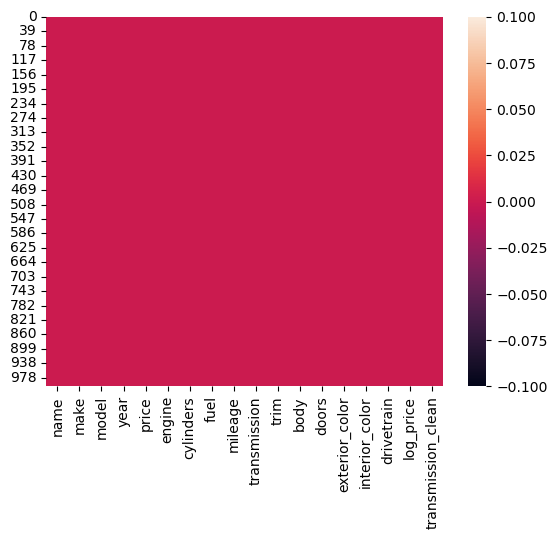

In [276]:
sns.heatmap(data = df.isna())

### Numeric Clms

In [277]:
df[df['price'] == 0]

,name,make,model,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain,log_price,transmission_clean
94,2024 Audi SQ5 Premium Plus,Audi,SQ5,2024,0.0,oled Turbo Premium Unleaded V-6 3.0 L/183,6.0,Gasoline,14.0,Automatic,Premium Plus,SUV,4.0,Ultra Blue Metallic,Black,All-wheel Drive,0.0,automatic


In [278]:
df[df['doors'] == 0]

,name,make,model,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain,log_price,transmission_clean


In [279]:
df[df['log_price'] == 0]

,name,make,model,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain,log_price,transmission_clean
94,2024 Audi SQ5 Premium Plus,Audi,SQ5,2024,0.0,oled Turbo Premium Unleaded V-6 3.0 L/183,6.0,Gasoline,14.0,Automatic,Premium Plus,SUV,4.0,Ultra Blue Metallic,Black,All-wheel Drive,0.0,automatic


In [280]:
m = df[df['make']=='Audi']['price'].mean()
df['price'] = df['price'].replace(0.0,m)

In [281]:
from sklearn.impute import SimpleImputer

# Create a group-based mean dictionary
group_means = df[df['mileage'] > 0].groupby(['make', 'model'])['mileage'].mean()

def group_imputer(row):
    if row['mileage'] == 0:
        key = (row['make'], row['model'])
        return group_means.get(key, df[df['mileage'] > 0]['mileage'].mean())
    return row['mileage']

df['mileage'] = df.apply(group_imputer, axis=1)

In [282]:
df[df['mileage'] == 0]

,name,make,model,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain,log_price,transmission_clean


In [283]:
df[df['doors'] == 0]

,name,make,model,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain,log_price,transmission_clean


In [284]:
df.to_csv('null_cleaned_data1 .csv',index= False)

In [285]:
dd = pd.read_csv('null_cleaned_data1 .csv')
dd.head(2)

,name,make,model,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain,log_price,transmission_clean
0,2024 Jeep Wagoneer Series II,Jeep,Wagoneer,2024,74600.0,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,Series II,SUV,4.0,White,Global Black,Four-wheel Drive,11.219909,8-speed automatic
1,2024 Jeep Grand Cherokee Laredo,Jeep,Grand Cherokee,2024,50170.0,OHV,6.0,Gasoline,1.0,8-Speed Automatic,Laredo,SUV,4.0,Metallic,Global Black,Four-wheel Drive,10.823192,8-speed automatic


### categorical clms

In [286]:
print(len(df.trim.value_counts()))

196


In [287]:
print(len(df.body.value_counts()))

8


In [288]:
print(len(df.model.value_counts()))

152


In [289]:
print(len(df.make.value_counts()))

28


In [290]:
print(len(df.fuel.value_counts()))

7


In [291]:
print(len(df.exterior_color.value_counts()))

263


In [292]:
print(len(df.interior_color.value_counts()))

90


In [293]:
print(len(df.drivetrain.value_counts()))

4


In [294]:
print(len(df.transmission_clean.value_counts()))

9


In [295]:
# Check your data structure
model_stats = df['model'].value_counts()
print(f"Total records: {len(df)}")
print(f"Unique models: {len(model_stats)}")
print(f"Average records per model: {len(df) / len(model_stats):.1f}")
print(f"Models with < 5 records: {len(model_stats[model_stats < 5])}")

Total records: 999
Unique models: 152
Average records per model: 6.6
Models with < 5 records: 101


In [296]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 1001
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                999 non-null    object 
 1   make                999 non-null    object 
 2   model               999 non-null    object 
 3   year                999 non-null    int64  
 4   price               999 non-null    float64
 5   engine              999 non-null    object 
 6   cylinders           999 non-null    float64
 7   fuel                999 non-null    object 
 8   mileage             999 non-null    float64
 9   transmission        999 non-null    object 
 10  trim                999 non-null    object 
 11  body                999 non-null    object 
 12  doors               999 non-null    float64
 13  exterior_color      999 non-null    object 
 14  interior_color      999 non-null    object 
 15  drivetrain          999 non-null    object 
 16  log_price   

In [ ]:
from category_encoders import LeaveOneOutEncoder

model_counts = df['model'].value_counts()
rare_models = model_counts[model_counts < 5].index
# Before encoding, use other features to create better groupings
df['price_segment'] = np.where(df['price'] > 50000, 'Luxury', 
                              np.where(df['price'] > 25000, 'Mid', 'Budget'))
# Group rare models WITHIN price segments
luxury_rare = [model for model in rare_models if df[df['model'] == model]['price'].mean() > 50000]
budget_rare = [model for model in rare_models if df[df['model'] == model]['price'].mean() < 10000]

df['model_grouped'] = df['model'].replace(luxury_rare, 'Luxury')

df['model_grouped'] = df['model_grouped'].replace(budget_rare, 'Budget')

# Then apply Leave-One-Out to the grouped version
encoder = LeaveOneOutEncoder(cols=['model_grouped'])
df['model_encoded'] = encoder.fit_transform(df['model_grouped'], df['price'])

In [298]:
import pandas as pd
import re

def categorize_exterior_color(color_name):
    """
    Categorize exterior color names into standardized families
    """
    if pd.isna(color_name):
        return 'Unknown'
    
    color = str(color_name).lower().strip()
    
    # Remove common modifiers and clean text
    color = re.sub(r'\b(clearcoat|metallic|pearl|tricoat|matte|glossy|premium|effect|tinted|coat|mica|ii)\b', '', color)
    color = re.sub(r'[\/\\\-\+]', ' ', color)
    color = re.sub(r'\s+', ' ', color).strip()
    
    # Color to family mapping
    if any(word in color for word in ['white', 'snow', 'glacier', 'ice', 'polar', 'pearl', 'oxford', 'summit', 'aspen', 'crystal']):
        return 'White'
    if any(word in color for word in ['black', 'ebony', 'onyx', 'obsidian', 'midnight', 'jet', 'phantom', 'caviar', 'sapphire']):
        return 'Black'
    if any(word in color for word in ['gray', 'grey', 'granite', 'graphite', 'steel', 'slate', 'carbon', 'magnetic', 'machine', 'titanium']):
        return 'Gray'
    if any(word in color for word in ['silver', 'sterling', 'pyrite', 'lunar', 'platinum', 'aluminum', 'chrome']):
        return 'Silver'
    if any(word in color for word in ['blue', 'ocean', 'navy', 'azure', 'deep', 'electric', 'twilight', 'velocity', 'hydro']):
        return 'Blue'
    if any(word in color for word in ['red', 'radiant', 'race', 'rapid', 'ruby', 'scarlet', 'crimson', 'volcanic', 'flame']):
        return 'Red'
    if any(word in color for word in ['green', 'jungle', 'forest', 'emerald', 'olive', 'cactus', 'sage', 'riverrock', 'eruption']):
        return 'Green'
    if any(word in color for word in ['yellow', 'gold', 'wheatland', 'sunflower', 'mustard']):
        return 'Yellow'
    if any(word in color for word in ['orange', 'bronze', 'copper', 'tamale', 'cayenne', 'pumpkin']):
        return 'Orange'
    if any(word in color for word in ['brown', 'chocolate', 'espresso', 'java', 'caramel', 'walnut', 'mojave', 'umber']):
        return 'Brown'
    if any(word in color for word in ['purple', 'violet', 'lavender', 'lilac', 'magenta']):
        return 'Purple'
    
    return 'Other'

# Apply the categorization to exterior color column
df['exterior_color_clean'] = df['exterior_color'].apply(categorize_exterior_color)

# Group rare colors
color_counts = df['exterior_color_clean'].value_counts()
rare_colors = color_counts[color_counts < 10].index
df['exterior_color_clean'] = df['exterior_color_clean'].replace(rare_colors, 'Other')

print("Exterior color transformation complete!")
print("Unique exterior colors now:", df['exterior_color_clean'].nunique())
print(df['exterior_color_clean'].value_counts())

# Optional: Replace original column or keep both
# df['exterior_color'] = df['exterior_color_clean']

Exterior color transformation complete!
Unique exterior colors now: 10
exterior_color_clean
White     366
Black     176
Gray      142
Other     103
Silver     70
Blue       53
Red        42
Green      19
Yellow     16
Orange     12
Name: count, dtype: int64


In [330]:
df['Drive_type'] = df['drivetrain'].replace({
    'All-wheel Drive': '4WD/AWD',
    'Four-wheel Drive': '4WD/AWD',
    'Front-wheel Drive': 'FWD',
    'Rear-wheel Drive': 'RWD'
})

In [331]:
df['Drive_type'].value_counts()

Drive_type
4WD/AWD    788
FWD        138
RWD         73
Name: count, dtype: int64

In [332]:
import pandas as pd
import re

def categorize_interior_color(color_name):
    """
    Categorize interior color names into standardized families
    """
    if pd.isna(color_name):
        return 'Unknown'
    
    color = str(color_name).lower().strip()
    
    # Remove common modifiers and clean text
    color = re.sub(r'\b(premium|cloth|leather|trimmed|softex|trim|accents|stitching|front|color)\b', '', color)
    color = re.sub(r'[\/\\\-\+]', ' ', color)
    color = re.sub(r'\s+', ' ', color).strip()
    color = re.sub(r'\bw\/\b', 'with ', color)  # Replace "w/" with "with"
    
    # Color to family mapping
    if any(word in color for word in ['black', 'ebony', 'onyx', 'jet', 'noir', 'bk', 'graphite']):
        return 'Black'
    if any(word in color for word in ['gray', 'grey', 'graphite', 'steel', 'ash', 'pewter', 'space', 'galvanized']):
        return 'Gray'
    if any(word in color for word in ['beige', 'tan', 'pebble', 'sandstone', 'dune', 'camel', 'macchiato']):
        return 'Beige'
    if any(word in color for word in ['brown', 'cognac', 'espresso', 'java', 'caramel', 'walnut', 'mojave', 'umber']):
        return 'Brown'
    if any(word in color for word in ['red', 'ruby', 'tacora', 'monaco', 'crimson', 'scarlet']):
        return 'Red'
    if any(word in color for word in ['white', 'oyster', 'salt', 'platinum', 'alpine']):
        return 'White'
    if any(word in color for word in ['green', 'dark green', 'olive', 'sage']):
        return 'Green'
    if any(word in color for word in ['blue', 'navy', 'santorini', 'twilight']):
        return 'Blue'
    
    return 'Other'

# Apply the categorization to interior color column
df['interior_color_clean'] = df['interior_color'].apply(categorize_interior_color)

# Group rare colors
color_counts = df['interior_color_clean'].value_counts()
rare_colors = color_counts[color_counts < 10].index
df['interior_color_clean'] = df['interior_color_clean'].replace(rare_colors, 'Other')

print("Interior color transformation complete!")
print("Unique interior colors now:", df['interior_color_clean'].nunique())
print(df['interior_color_clean'].value_counts())

# Optional: Replace original column or keep both
# df['interior_color'] = df['interior_color_clean']

Interior color transformation complete!
Unique interior colors now: 5
interior_color_clean
Black    802
Gray     103
Other     68
Brown     15
Beige     11
Name: count, dtype: int64


In [302]:
df.columns

Index(['name', 'make', 'model', 'year', 'price', 'engine', 'cylinders', 'fuel',
       'mileage', 'transmission', 'trim', 'body', 'doors', 'exterior_color',
       'interior_color', 'drivetrain', 'log_price', 'transmission_clean',
       'price_segment', 'model_grouped', 'model_encoded',
       'exterior_color_clean', 'interior_color_clean'],
      dtype='object')

In [ ]:
from category_encoders import LeaveOneOutEncoder
encoder = LeaveOneOutEncoder()
df['interior_encoded'] = encoder.fit_transform(df['interior_color_clean'],df['price'])


encoder = LeaveOneOutEncoder(cols=['make'])
df['make_encoded'] = encoder.fit_transform(df['make'], df['price'])

encoder = LeaveOneOutEncoder()
df['exterior_encoded'] = encoder.fit_transform(df['exterior_color_clean'],df['price'])

# encoder = LeaveOneOutEncoder(cols=['model_grouped'])
# df['model_encoded'] = encoder.fit_transform(df['model_grouped'], df['price'])

In [305]:
# from category_encoders import LeaveOneOutEncoder
# encoder = LeaveOneOutEncoder()
# df['transmission_encoded'] = encoder.fit_transform(df['transmission_clean'],df['price'])

In [307]:
df1 = pd.get_dummies(df,columns = ['fuel','body','drivetrain'],drop_first=True)

In [308]:
df.to_csv('final cleaned data.csv',index=False)

In [309]:
cat = df.select_dtypes(include=['object']).columns

In [310]:
num = df.select_dtypes(include=['int64','float64']).columns

In [311]:
df.head(3)

,name,make,model,year,price,engine,cylinders,fuel,mileage,transmission,...,log_price,transmission_clean,price_segment,model_grouped,model_encoded,exterior_color_clean,interior_color_clean,exterior_encoded,interior_encoded,make_encoded
0,2024 Jeep Wagoneer Series II,Jeep,Wagoneer,2024,74600.0,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,...,11.219909,8-speed automatic,Luxury,Wagoneer,73554.600000,White,Black,53092.093151,50588.787297,53175.290155
1,2024 Jeep Grand Cherokee Laredo,Jeep,Grand Cherokee,2024,50170.0,OHV,6.0,Gasoline,1.0,8-Speed Automatic,...,10.823192,8-speed automatic,Luxury,Grand Cherokee,47198.392857,Other,Black,45911.333333,50619.286673,53301.870466
2,2024 GMC Yukon XL Denali,GMC,Yukon XL,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",8.0,Gasoline,3.0,Automatic,...,11.476376,automatic,Luxury,Luxury,70350.410354,White,Other,53032.339726,46566.910448,59621.818182


In [313]:
engine_categories = {
    'Turbocharged': ['turbo', 'twin turbo', 'intercooled'],
    'Hybrid': ['hybrid'],
    'Diesel': ['diesel'],
    'Electric': ['zev', 'ev', 'electric'],
    'Gasoline': ['gasoline', 'unleaded', 'premium unleaded'],
    'VVT': ['vvt', 'cvvt', 'cvvd', 'variable valve'],
    'DOHC': ['dohc'],
    'SOHC': ['sohc'],
    'MPFI': ['mpfi'],
    'GDI': ['gdi'],
    'PDI': ['pdi'],
    'DDI': ['ddi'],
    'OHV': ['ohv'],
}


In [314]:
import numpy as np

def categorize_engine(engine_text):
    engine_text = str(engine_text).lower()
    for category, keywords in engine_categories.items():
        for keyword in keywords:
            if keyword in engine_text:
                return category
    return np.nan  # If no match found


In [315]:
df['engine_category'] = df['engine'].apply(categorize_engine)
df['engine_category'].value_counts()

engine_category
Turbocharged    400
DOHC            141
Gasoline        137
VVT              50
MPFI             48
Hybrid           25
OHV              22
GDI              21
Electric         18
SOHC             16
Diesel            3
Name: count, dtype: int64

In [321]:
df['engine_category'] = df['engine_category'].fillna(df['engine_category'].mode()[0])

In [339]:
trim_categories = {
    'Base': ['base', 'standard', 'work van', 'crew', 'wt'],
    'Luxury': ['limited', 'platinum', 'premium', 'luxury', 'avenir', 'calligraphy', 'essence', 'denali ultimate'],
    'Sport': ['sport', 'gt', 'r/t', 'sx', 'st-line', 'xrt', 'trailhawk', 'rubicon', 'wildtrak', 'power wagon', 'scat pack', 'zr2'],
    'Off-Road': ['4x4', 'overland', 'big bend', 'trail', 'sahara', 'summit', 'timberline'],
    'Performance': ['m60', 'm70', 'm50', 'm60i', 'xdrive', 'sdrive', 'quattro', 'f sport', 'rs', 'sv awd', 'gt plus awd'],
    'Hybrid/Electric': ['hybrid', 'edrive', 'ev', 'zev', 'electric'],
    'Mid': ['sel', 'se', 'sv', 'lt', 'xlt', 'ex', 'lx', 'sl', 'sxt', 'preferred', 'laredo', 'latitude', 'laramie', 'slt'],
    'Special Edition': ['anniversary', 'edition', 'prestige', 'select', 'elite', 'ultimate', 'carbide', 'dark theme', 'bright theme', 'disney100'],
}


In [340]:
import numpy as np

def categorize_trim(trim_text):
    trim_text = str(trim_text).lower()
    for category, keywords in trim_categories.items():
        for keyword in keywords:
            if keyword in trim_text:
                return category
    return np.nan  # If no match found


In [341]:
df['trim_category'] = df['trim'].apply(categorize_trim)


In [347]:
df['trim_category'] = df['trim_category'].fillna(df['trim_category'].mode()[0])

In [353]:

def feature_engineering(df):
    df = df.copy()
    df['car_age'] = 2025 - df['year']
    df['mileage_per_year'] = df['mileage'] / (df['car_age'] + 1)
    return df
df = feature_engineering(df)

In [354]:
df.to_csv('final_cleaned_data.csv',index=False)

In [7]:
import pandas as pd
dd = pd.read_csv('final_cleaned_data.csv')

In [8]:
dd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  999 non-null    object 
 1   make                  999 non-null    object 
 2   model                 999 non-null    object 
 3   year                  999 non-null    int64  
 4   price                 999 non-null    float64
 5   engine                999 non-null    object 
 6   cylinders             999 non-null    float64
 7   fuel                  999 non-null    object 
 8   mileage               999 non-null    float64
 9   transmission          999 non-null    object 
 10  trim                  999 non-null    object 
 11  body                  999 non-null    object 
 12  doors                 999 non-null    float64
 13  exterior_color        999 non-null    object 
 14  interior_color        999 non-null    object 
 15  drivetrain            9

In [9]:
ndf = dd[['year', 'price','cylinders', 'fuel',
       'mileage','body', 'doors','Drive_type','transmission_clean',
       'model_encoded','exterior_encoded','interior_encoded', 'make_encoded',
       'engine_category','trim_category','car_age','mileage_per_year','log_price']]

In [10]:
ndf.head()

,year,price,cylinders,fuel,mileage,body,doors,Drive_type,transmission_clean,model_encoded,exterior_encoded,interior_encoded,make_encoded,engine_category,trim_category,car_age,mileage_per_year,log_price
0,2024,74600.0,6.0,Gasoline,10.0,SUV,4.0,4WD/AWD,8-speed automatic,73554.600000,53092.093151,50588.787297,53175.290155,Turbocharged,Mid,1,5.000000,11.219909
1,2024,50170.0,6.0,Gasoline,1.0,SUV,4.0,4WD/AWD,8-speed automatic,47198.392857,45911.333333,50619.286673,53301.870466,OHV,Mid,1,0.500000,10.823192
2,2024,96410.0,8.0,Gasoline,3.0,SUV,4.0,4WD/AWD,automatic,70350.410354,53032.339726,46566.910448,59621.818182,Gasoline,Mid,1,1.500000,11.476376
3,2023,46835.0,8.0,Gasoline,32.0,SUV,4.0,4WD/AWD,8-speed automatic,47574.500000,53168.161644,50623.450218,44094.310345,MPFI,Performance,2,10.666667,10.754407
4,2024,81663.0,6.0,Diesel,10.0,Pickup Truck,4.0,4WD/AWD,6-speed automatic,70723.039216,48573.840580,50579.969569,67993.705128,Turbocharged,Mid,1,5.000000,11.310369


In [484]:
ndf.columns

Index(['year', 'price', 'cylinders', 'fuel', 'mileage', 'body', 'doors',
       'Drive_type', 'transmission_clean', 'model_encoded', 'exterior_encoded',
       'interior_encoded', 'make_encoded', 'engine_category', 'trim_category',
       'car_age', 'mileage_per_year', 'log_price'],
      dtype='object')

In [11]:
ndf = ndf.rename(columns={'transmission_clean': 'transmission',
                          'Drive_type': 'drive_type',
                          'model_encoded':'model',
                          'exterior_encoded':'exterior_color', 
                          'interior_encoded':'interior_color', 
                          'make_encoded':'make',
                          'engine_category':'engine', 
                          'trim_category':'trim'},
                          )

In [12]:
ndf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              999 non-null    int64  
 1   price             999 non-null    float64
 2   cylinders         999 non-null    float64
 3   fuel              999 non-null    object 
 4   mileage           999 non-null    float64
 5   body              999 non-null    object 
 6   doors             999 non-null    float64
 7   drive_type        999 non-null    object 
 8   transmission      999 non-null    object 
 9   model             999 non-null    float64
 10  exterior_color    999 non-null    float64
 11  interior_color    999 non-null    float64
 12  make              999 non-null    float64
 13  engine            999 non-null    object 
 14  trim              999 non-null    object 
 15  car_age           999 non-null    int64  
 16  mileage_per_year  999 non-null    float64
 1

In [13]:
cat = ndf.select_dtypes(include=['object']).columns.to_list()
cat

['fuel', 'body', 'drive_type', 'transmission', 'engine', 'trim']

In [14]:
for i in cat:
    print(ndf[i].value_counts())


fuel
Gasoline                671
Hybrid                  137
Electric                 97
Diesel                   73
PHEV Hybrid Fuel         16
E85 Flex Fuel             4
Diesel (B20 capable)      1
Name: count, dtype: int64
body
SUV              706
Pickup Truck     154
Sedan             79
Cargo Van         35
Passenger Van     13
Hatchback         10
Convertible        1
Minivan            1
Name: count, dtype: int64
drive_type
4WD/AWD    788
FWD        138
RWD         73
Name: count, dtype: int64
transmission
8-speed automatic     364
automatic             238
6-speed automatic     114
9-speed automatic      70
1-speed automatic      69
10-speed automatic     60
cvt                    58
7-speed automatic      23
variable                3
Name: count, dtype: int64
engine
Turbocharged    518
DOHC            141
Gasoline        137
VVT              50
MPFI             48
Hybrid           25
OHV              22
GDI              21
Electric         18
SOHC             16
Diesel      

In [15]:
ndf = pd.get_dummies(ndf, columns=cat, drop_first=True, dtype=int)


In [16]:
ndf.head()

,year,price,cylinders,mileage,doors,model,exterior_color,interior_color,make,car_age,...,engine_SOHC,engine_Turbocharged,engine_VVT,trim_Hybrid/Electric,trim_Luxury,trim_Mid,trim_Off-Road,trim_Performance,trim_Special Edition,trim_Sport
0,2024,74600.0,6.0,10.0,4.0,73554.600000,53092.093151,50588.787297,53175.290155,1,...,0,1,0,0,0,1,0,0,0,0
1,2024,50170.0,6.0,1.0,4.0,47198.392857,45911.333333,50619.286673,53301.870466,1,...,0,0,0,0,0,1,0,0,0,0
2,2024,96410.0,8.0,3.0,4.0,70350.410354,53032.339726,46566.910448,59621.818182,1,...,0,0,0,0,0,1,0,0,0,0
3,2023,46835.0,8.0,32.0,4.0,47574.500000,53168.161644,50623.450218,44094.310345,2,...,0,0,0,0,0,0,0,1,0,0
4,2024,81663.0,6.0,10.0,4.0,70723.039216,48573.840580,50579.969569,67993.705128,1,...,0,1,0,0,0,1,0,0,0,0


In [18]:
ndf.corr()['price'].sort_values(ascending=False)

price                              1.000000
model                              0.824109
make                               0.655998
log_price                          0.654508
cylinders                          0.375570
engine_Turbocharged                0.253628
body_Pickup Truck                  0.234652
fuel_Electric                      0.221210
interior_color                     0.196434
transmission_10-speed automatic    0.174999
exterior_color                     0.173912
trim_Performance                   0.129090
transmission_automatic             0.126264
trim_Hybrid/Electric               0.113376
trim_Off-Road                      0.099354
mileage                            0.095580
mileage_per_year                   0.093568
engine_Electric                    0.078337
engine_Diesel                      0.063945
fuel_Diesel (B20 capable)          0.063684
drive_type_RWD                     0.060003
trim_Luxury                        0.055947
engine_GDI                      

In [21]:
nd = ndf[ndf.columns[abs(ndf.corr()['price']) >=0.2]]
x = nd.drop(columns=['price','log_price'])

# x = nd[['cylinders', 'model', 'make', 'fuel_Electric', 'fuel_Gasoline',
#        'body_Pickup Truck', 'drive_type_FWD', 'transmission_cvt',
#        'engine_Turbocharged', 'trim_Mid']]
# x = nd[['cylinders', 'model', 'make', 'fuel_Gasoline',
#        'drive_type_FWD']]
y = nd['price']

In [160]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

scalar  = StandardScaler()
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

model = LinearRegression()

model.fit(x_train,y_train)
pred = model.predict(x_test)
print(r2_score(y_test,pred))

model = RandomForestRegressor(max_depth=12)
model.fit(x_train,y_train)
pred = model.predict(x_test)
y_train_pred = model.predict(x_train)
print('traindata:',r2_score(y_train,y_train_pred))
print('testdata:',r2_score(y_test,pred))

from xgboost import XGBRegressor
model = XGBRegressor(max_depth=4,learning_rate= 0.3,n_estimators = 112,
                     subsample = 0.8,colsample_bytree=0.8,reg_alpha=0.2,
                     reg_lambda=1,gamma=9)#9max_depth=8,learning_rate= 0.3,n_estimators = 112,subsample = 0.8,colsample_bytree=0.8--->0.9700049298112811
model.fit(
    x_train, y_train,
    eval_set=[(x_test, y_test)],
    early_stopping_rounds=10,
    verbose=True
)

pred = model.predict(x_test)
r2_score(y_test,pred)


0.7307506198803189
traindata: 0.9862937235284592
testdata: 0.9023663227648772


TypeError: XGBModel.fit() got an unexpected keyword argument 'early_stopping_rounds'

In [144]:
from xgboost import XGBRegressor
model = XGBRegressor(max_depth=4,learning_rate= 0.3,n_estimators = 120,
                     subsample = 0.8,colsample_bytree=0.8,reg_alpha=0.2,
                     reg_lambda=1,gamma=9)#9max_depth=8,learning_rate= 0.3,n_estimators = 112,subsample = 0.8,colsample_bytree=0.8--->0.9700049298112811
model.fit(x_train,y_train)
pred = model.predict(x_test)
r2_score(y_test,pred)
# model = XGBRegressor(max_depth=8,learning_rate= 0.3,n_estimators = 112,
#                      subsample = 0.8,colsample_bytree=0.8,reg_alpha=0.2,
#                      reg_lambda=1,gamma=9,booster='gbtree')

0.9238714542133772

In [164]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0
)

model.fit(
    x_train, y_train,
    eval_set=[(x_test, y_test)],
    verbose=True
)

pred = model.predict(x_test)
print('test:',r2_score(y_test,pred))
y_pred_train = model.predict(x_train)
print('Train:',r2_score(y_train,y_pred_train))


[0]	validation_0-rmse:15297.86273
[1]	validation_0-rmse:14602.40060
[2]	validation_0-rmse:13947.72518
[3]	validation_0-rmse:13312.73411
[4]	validation_0-rmse:12730.91885
[5]	validation_0-rmse:12223.31829
[6]	validation_0-rmse:11763.93484
[7]	validation_0-rmse:11290.47428
[8]	validation_0-rmse:10827.48306
[9]	validation_0-rmse:10336.73938
[10]	validation_0-rmse:9899.09239
[11]	validation_0-rmse:9505.81964
[12]	validation_0-rmse:9132.66661
[13]	validation_0-rmse:8781.16084
[14]	validation_0-rmse:8489.70344
[15]	validation_0-rmse:8168.47008
[16]	validation_0-rmse:7876.47237
[17]	validation_0-rmse:7576.62378
[18]	validation_0-rmse:7310.54496
[19]	validation_0-rmse:7066.77018
[20]	validation_0-rmse:6826.93149
[21]	validation_0-rmse:6627.79148
[22]	validation_0-rmse:6422.87633
[23]	validation_0-rmse:6212.82114
[24]	validation_0-rmse:6029.19696
[25]	validation_0-rmse:5865.40191
[26]	validation_0-rmse:5739.27810
[27]	validation_0-rmse:5604.30550
[28]	validation_0-rmse:5498.78565
[29]	validatio

## Freqvency encoding

In [50]:
d = pd.read_csv('final_cleaned_data.csv')

In [51]:
d.head()

,name,make,model,year,price,engine,cylinders,fuel,mileage,transmission,...,exterior_color_clean,interior_color_clean,exterior_encoded,interior_encoded,make_encoded,engine_category,Drive_type,trim_category,car_age,mileage_per_year
0,2024 Jeep Wagoneer Series II,Jeep,Wagoneer,2024,74600.0,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,...,White,Black,53092.093151,50588.787297,53175.290155,Turbocharged,4WD/AWD,Mid,1,5.000000
1,2024 Jeep Grand Cherokee Laredo,Jeep,Grand Cherokee,2024,50170.0,OHV,6.0,Gasoline,1.0,8-Speed Automatic,...,Other,Black,45911.333333,50619.286673,53301.870466,OHV,4WD/AWD,Mid,1,0.500000
2,2024 GMC Yukon XL Denali,GMC,Yukon XL,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",8.0,Gasoline,3.0,Automatic,...,White,Other,53032.339726,46566.910448,59621.818182,Gasoline,4WD/AWD,Mid,1,1.500000
3,2023 Dodge Durango Pursuit,Dodge,Durango,2023,46835.0,16V MPFI OHV,8.0,Gasoline,32.0,8-Speed Automatic,...,White,Black,53168.161644,50623.450218,44094.310345,MPFI,4WD/AWD,Performance,2,10.666667
4,2024 RAM 3500 Laramie,RAM,3500,2024,81663.0,24V DDI OHV Turbo Diesel,6.0,Diesel,10.0,6-Speed Automatic,...,Silver,Black,48573.840580,50579.969569,67993.705128,Turbocharged,4WD/AWD,Mid,1,5.000000


In [52]:
d = d[['year', 'price','cylinders', 'fuel',
       'mileage','body', 'doors','Drive_type','transmission_clean',
       'model_encoded','exterior_encoded','interior_encoded', 'make_encoded',
       'engine_category','trim_category','car_age','mileage_per_year']]

In [53]:
d = d.rename(columns={'transmission_clean': 'transmission',
                          'Drive_type': 'drive_type',
                          'model_encoded':'model',
                          'exterior_encoded':'exterior_color', 
                          'interior_encoded':'interior_color', 
                          'make_encoded':'make',
                          'engine_category':'engine', 
                          'trim_category':'trim'},
                          )

In [54]:
cat = d.select_dtypes(include=['object']).columns.to_list()
cat

['fuel', 'body', 'drive_type', 'transmission', 'engine', 'trim']

In [55]:
# List of categorical columns for frequency encoding
categorical_columns = ['fuel', 'body', 'drive_type', 'transmission', 'engine', 'trim']

# Perform frequency encoding
for col in categorical_columns:
    freq = d[col].value_counts()
    d[col + '_freq'] = d[col].map(freq)

# Display the first few rows to verify
d.head()

,year,price,cylinders,fuel,mileage,body,doors,drive_type,transmission,model,...,engine,trim,car_age,mileage_per_year,fuel_freq,body_freq,drive_type_freq,transmission_freq,engine_freq,trim_freq
0,2024,74600.0,6.0,Gasoline,10.0,SUV,4.0,4WD/AWD,8-speed automatic,73554.600000,...,Turbocharged,Mid,1,5.000000,671,706,788,364,518,485
1,2024,50170.0,6.0,Gasoline,1.0,SUV,4.0,4WD/AWD,8-speed automatic,47198.392857,...,OHV,Mid,1,0.500000,671,706,788,364,22,485
2,2024,96410.0,8.0,Gasoline,3.0,SUV,4.0,4WD/AWD,automatic,70350.410354,...,Gasoline,Mid,1,1.500000,671,706,788,238,137,485
3,2023,46835.0,8.0,Gasoline,32.0,SUV,4.0,4WD/AWD,8-speed automatic,47574.500000,...,MPFI,Performance,2,10.666667,671,706,788,364,48,62
4,2024,81663.0,6.0,Diesel,10.0,Pickup Truck,4.0,4WD/AWD,6-speed automatic,70723.039216,...,Turbocharged,Mid,1,5.000000,73,154,788,114,518,485


In [56]:
fd = d.drop(columns=cat)

In [57]:
fd.head()

,year,price,cylinders,mileage,doors,model,exterior_color,interior_color,make,car_age,mileage_per_year,fuel_freq,body_freq,drive_type_freq,transmission_freq,engine_freq,trim_freq
0,2024,74600.0,6.0,10.0,4.0,73554.600000,53092.093151,50588.787297,53175.290155,1,5.000000,671,706,788,364,518,485
1,2024,50170.0,6.0,1.0,4.0,47198.392857,45911.333333,50619.286673,53301.870466,1,0.500000,671,706,788,364,22,485
2,2024,96410.0,8.0,3.0,4.0,70350.410354,53032.339726,46566.910448,59621.818182,1,1.500000,671,706,788,238,137,485
3,2023,46835.0,8.0,32.0,4.0,47574.500000,53168.161644,50623.450218,44094.310345,2,10.666667,671,706,788,364,48,62
4,2024,81663.0,6.0,10.0,4.0,70723.039216,48573.840580,50579.969569,67993.705128,1,5.000000,73,154,788,114,518,485


In [58]:
x = fd.drop(columns=['price'])
y = fd['price']

In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

scalar  = StandardScaler()
dx_train,dx_test,dy_train,dy_test = train_test_split(x,y,test_size=0.2,random_state=0)
dx_train = scalar.fit_transform(dx_train)
dx_test = scalar.transform(dx_test)

from xgboost import XGBRegressor
model = XGBRegressor(max_depth=8)
model.fit(dx_train,dy_train)
dpred = model.predict(dx_test)
r2_score(dy_test,dpred)

0.9017608872610607